# Thermal Expansion Coefficient of LJ Glasses

## What we are after

The isobaric thermal expansion coefficient:
$$\alpha = \frac{1}{V}\frac{\partial V}{\partial T}\bigg|_p$$

Using a thermodynamic identity this becomes:
$$\boxed{\alpha = \frac{1}{K} \cdot \frac{\partial p}{\partial T}\bigg|_V}$$

So really we only need two numbers: $K$ (bulk modulus), from `3dlj_elasticity_analysis.c`, and $\partial p/\partial T$, the slope of pressure vs temperature measured by `3dlj_NVT_NH.c`.

---

## Potential

$$\varphi(r) = 4\left(\frac{1}{r^{12}} - \frac{1}{r^{6}} + c_6 r^6 + c_4 r^4 + c_2 r^2 + c_0\right)$$

with cutoff at $r/\sigma = 2.5$, $N=4000$, $\rho=0.541$.

---

## Compilation

```bash
gcc -O2 -o elasticity 3dlj_elasticity_analysis.c -lm
gcc -O2 -o nvt        3dlj_NVT_NH.c              -lm
```

---

## Getting the bulk modulus

```bash
./elasticity
```

Reads all 10 glass files `3dlj_N4000_s00000.dat` through `3dlj_N4000_s00009.dat` and writes **`3dlj_elasticity_N4000_s000.dat`**:

```
# serial       u_per_N       pressure      G           K           first_order  second_order
0          ...
...
9          ...
```

---

## Running NVT at several temperatures

```bash
./nvt  <temperature>  <glass_number>
# e.g.: ./nvt 0.01 3   ->  nvt_lj_T0.0100_g3.dat
```

Each file has 4 columns: `time   KE/N   PE/N   P_virial`

**`P_virial` is what we care about** — pressure without the kinetic term, which is exactly what the theory predicts.


## Pressure in a simulation

In a simulation with periodic boundary conditions and pairwise interactions, the total pressure has two contributions:

$$P_\text{total} = \underbrace{\frac{Nk_BT}{V}}_{\text{kinetic}} + \underbrace{P_\text{vir}}_{\text{virial}}$$

The kinetic term $Nk_BT/V$ is the ideal gas contribution — it comes from atoms moving around and bouncing off imaginary walls. By equipartition it is always exactly $Nk_BT/V$, for any system regardless of interactions or structure.

---

## Why we only care about $P_\text{vir}$

Taking $\partial/\partial T$ of the total pressure at fixed $V$:

$$\left.\frac{\partial P_\text{total}}{\partial T}\right|_V = \underbrace{\frac{Nk_B}{V}}_{\text{trivial constant}} + \left.\frac{\partial P_\text{vir}}{\partial T}\right|_V$$

The kinetic contribution to $\partial P/\partial T$ is simply $Nk_B/V$ — a known constant carrying no structural information whatsoever. It is the same for a glass, a liquid, a crystal, or an ideal gas. Its contribution to $\alpha$ is:

$$\alpha_\text{kinetic} = \frac{1}{K}\cdot\frac{Nk_B}{V}$$


---
# Analysis: per-glass approach


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR     = 'initial_files'                                   # directory containing all output files
TEMPERATURES = 0.000001, 0.000005, 0.000010, 0.000015, 0.000020, 0.000025, 0.000030, 0.000035, 0.000040
GLASSES      = list(range(10))                       # 0 through 9
SKIP         = 0.3                                   # discard first 30 % as equilibration
N_ATOMS      = 4000
RHO          = 0.541


## Loading the bulk modulus $K$ from `3dlj_elasticity_N4000_s000.dat`


In [23]:
elas = np.loadtxt(Path(DATA_DIR) / '3dlj_elasticity_N4000_s000.dat', comments='#')

# columns: serial  u_per_N  pressure  G  K  first_order  second_order
serials = elas[:, 0].astype(int)
u_per_N = elas[:, 1]   # potential energy per atom
P0      = elas[:, 2]   # T=0 virial pressure per glass
G       = elas[:, 3]   # shear modulus
K       = elas[:, 4]   # bulk modulus  ← what we need for alpha

# build per-glass K dict for lookup later
K_per_glass = {serials[i]: K[i] for i in range(len(serials))}
P0_per_glass = {serials[i]: P0[i] for i in range(len(serials))}

print(f"{'Glass':>6}  {'P0':>12}  {'G':>10}  {'K':>10}")
print("-" * 46)
for i in range(len(serials)):
    print(f"{serials[i]:>6}  {P0[i]:>12.6f}  {G[i]:>10.5f}  {K[i]:>10.5f}")

K_mean  = K.mean()
K_std   = K.std()
P0_mean = P0.mean()
print(f"\nMean K  = {K_mean:.5f}  (std = {K_std:.5f})")
print(f"Mean P0 = {P0_mean:.6f}")


 Glass            P0           G           K
----------------------------------------------
     0     -0.005257     6.54571    25.13948
     1     -0.029724     5.88891    24.93104
     2     -0.053969     6.44974    24.87555
     3     -0.030540     6.39477    24.98168
     4     -0.019372     6.29758    25.17090
     5     -0.005405     6.42531    25.13052
     6      0.010240     6.32129    25.23917
     7     -0.008402     6.33860    25.09090
     8     -0.020723     6.33727    25.02117
     9      0.004262     5.95359    25.12921

Mean K  = 25.07096  (std = 0.10887)
Mean P0 = -0.015889


## Loading NVT files — per glass

For each glass we store its own time-series data and fit $P_g(T)$ to get $dP/dT_g$. The per-glass thermal expansion is then $\alpha_g = dP/dT_g / K_g$, which is the right quantity to compare against $\alpha_\text{theory}$ per glass.

The error used for weighting is the time-series standard error of each glass's own production run.


In [24]:
def read_nvt(filepath, skip=SKIP):
    """Read one NVT output file. Columns: time  KE/N  PE/N  P_virial"""
    d      = np.loadtxt(filepath)
    n_skip = int(len(d) * skip)
    prod   = d[n_skip:]
    T_meas = (2.0 / 3.0) * prod[:, 1].mean()          # T = (2/3) <KE/N>
    P_mean = prod[:, 3].mean()
    P_err  = prod[:, 3].std() / np.sqrt(len(prod))    # time-series SEM
    return T_meas, P_mean, P_err


#  per-glass storage: pg_data[g] = list of (T_meas, P_mean, P_err) 
pg_data = {g: [] for g in GLASSES}

print(f"Loading per-glass NVT data...")
print(f"{'Glass':>6}  {'n_temps':>10}")
print("-" * 20)

for g in GLASSES:
    for T in TEMPERATURES:
        f = Path(DATA_DIR) / f'nvt_lj_T{T:.6f}_g{g}.dat'
        if f.exists():
            Tm, Pm, Pe = read_nvt(f)
            pg_data[g].append((Tm, Pm, Pe))
    
    print(f"{g:>6}  {len(pg_data[g]):>10}")

print(f"\nLoaded data for {len(pg_data)} glasses")


Loading per-glass NVT data...
 Glass     n_temps
--------------------
     0           9
     1           9
     2           9
     3           9
     4           9
     5           9
     6           9
     7           9
     8           9
     9           9

Loaded data for 10 glasses


## Fitting $P$ vs $T$ — per glass

Each glass gets its own weighted linear fit using its own time-series errors.


In [25]:
def weighted_linear_fit(T_vals, P_vals, P_errs):
    """Weighted least-squares P = a + b*T.  Returns (intercept, slope, err_intercept, err_slope)."""
    w = 1.0 / np.array(P_errs)**2
    A = np.column_stack([np.ones_like(T_vals), T_vals])
    M = A.T @ np.diag(w) @ A
    coeffs = np.linalg.solve(M, A.T @ (w * np.array(P_vals)))
    errs   = np.sqrt(np.diag(np.linalg.inv(M)))
    return coeffs[0], coeffs[1], errs[0], errs[1]


#  per-glass fits 
pg_fit = {}   # g -> (P0_fit, dPdT, P0_err, dPdT_err)

print(f"{'Glass':>6}  {'P0_elasticity':>14}  {'P0_fit':>12}  {'disc%':>7}  {'dPdT':>10}  {'dPdT_err':>10}")
print("-" * 70)
for g in GLASSES:
    pts = pg_data[g]
    if len(pts) < 3:
        print(f"  g={g}: only {len(pts)} temperature points — skipping")
        continue
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    Ev = np.array([p[2] for p in pts])
    a, b, ea, eb = weighted_linear_fit(Tv, Pv, Ev)
    pg_fit[g] = (a, b, ea, eb)
    disc = (a - P0[g]) / abs(P0[g]) * 100 if P0[g] != 0 else float('nan')
    print(f"  {g:>4}  {P0[g]:>14.6f}  {a:>12.6f}  {disc:>+7.2f}%  {b:>10.5f}  {eb:>10.5f}")


 Glass   P0_elasticity        P0_fit    disc%        dPdT    dPdT_err
----------------------------------------------------------------------
     0       -0.005257     -0.005254    +0.06%     3.98609     0.05655
     1       -0.029724     -0.029720    +0.02%     3.13629     0.08475
     2       -0.053969     -0.053973    -0.01%     3.94582     0.05451
     3       -0.030540     -0.030542    -0.01%     4.18745     0.05555
     4       -0.019372     -0.019373    -0.01%     4.03159     0.05137
     5       -0.005405     -0.005440    -0.65%    10.60391     0.11166
     6        0.010240      0.010243    +0.03%     3.90833     0.05556
     7       -0.008402     -0.008400    +0.02%     4.04378     0.05840
     8       -0.020723     -0.020723    -0.00%     4.50844     0.05669
     9        0.004262      0.004250    -0.27%     4.01028     0.05736


## Computing $\alpha$ — per glass

Each glass gets $\alpha_\text{numerical}[g] = dP/dT_g / K_g$.


In [26]:
#  per-glass alpha_numerical 
alpha_numerical = {}   # g -> alpha

print(f"{'Glass':>6}  {'K':>10}  {'dPdT':>10}  {'alpha_num':>12}  {'alpha_err':>12}")
print("-" * 58)
for g in GLASSES:
    if g not in pg_fit:
        continue
    _, dPdT_g, _, dPdT_err_g = pg_fit[g]
    Kg       = K_per_glass[g]
    alpha_g  = dPdT_g / Kg
    
    # Error propagation: α = dPdT / K
    # For per-glass, we use dPdT_err from the fit
    # For K uncertainty, we use K_std as typical uncertainty estimate
    # (ideally we'd have per-glass K uncertainties, but we don't)
    aerr_g   = abs(alpha_g) * np.sqrt((dPdT_err_g / dPdT_g)**2 + (K_std / Kg)**2)
    
    alpha_numerical[g] = alpha_g
    print(f"  {g:>4}  {Kg:>10.5f}  {dPdT_g:>10.5f}  {alpha_g:>+12.6e}  {aerr_g:>12.6e}")

alpha_num_mean = np.mean(list(alpha_numerical.values()))
alpha_num_std  = np.std(list(alpha_numerical.values()))
alpha_num_sem  = alpha_num_std / np.sqrt(len(alpha_numerical))

print()
print(f"  Mean alpha_numerical  = {alpha_num_mean:+.6e}  ±  {alpha_num_sem:.6e}  (SEM)")
print(f"  Std  alpha_numerical  = {alpha_num_std:.6e}")


 Glass           K        dPdT     alpha_num     alpha_err
----------------------------------------------------------
     0    25.13948     3.98609  +1.585592e-01  2.351735e-03
     1    24.93104     3.13629  +1.257985e-01  3.443570e-03
     2    24.87555     3.94582  +1.586224e-01  2.298513e-03
     3    24.98168     4.18745  +1.676210e-01  2.340634e-03
     4    25.17090     4.03159  +1.601689e-01  2.155120e-03
     5    25.13052    10.60391  +4.219535e-01  4.804567e-03
     6    25.23917     3.90833  +1.548517e-01  2.300466e-03
     7    25.09090     4.04378  +1.611652e-01  2.430300e-03
     8    25.02117     4.50844  +1.801850e-01  2.397555e-03
     9    25.12921     4.01028  +1.595863e-01  2.384863e-03

  Mean alpha_numerical  = +1.848512e-01  ±  2.532018e-02  (SEM)
  Std  alpha_numerical  = 8.006944e-02


## Per-glass $P$ vs $T$ plots


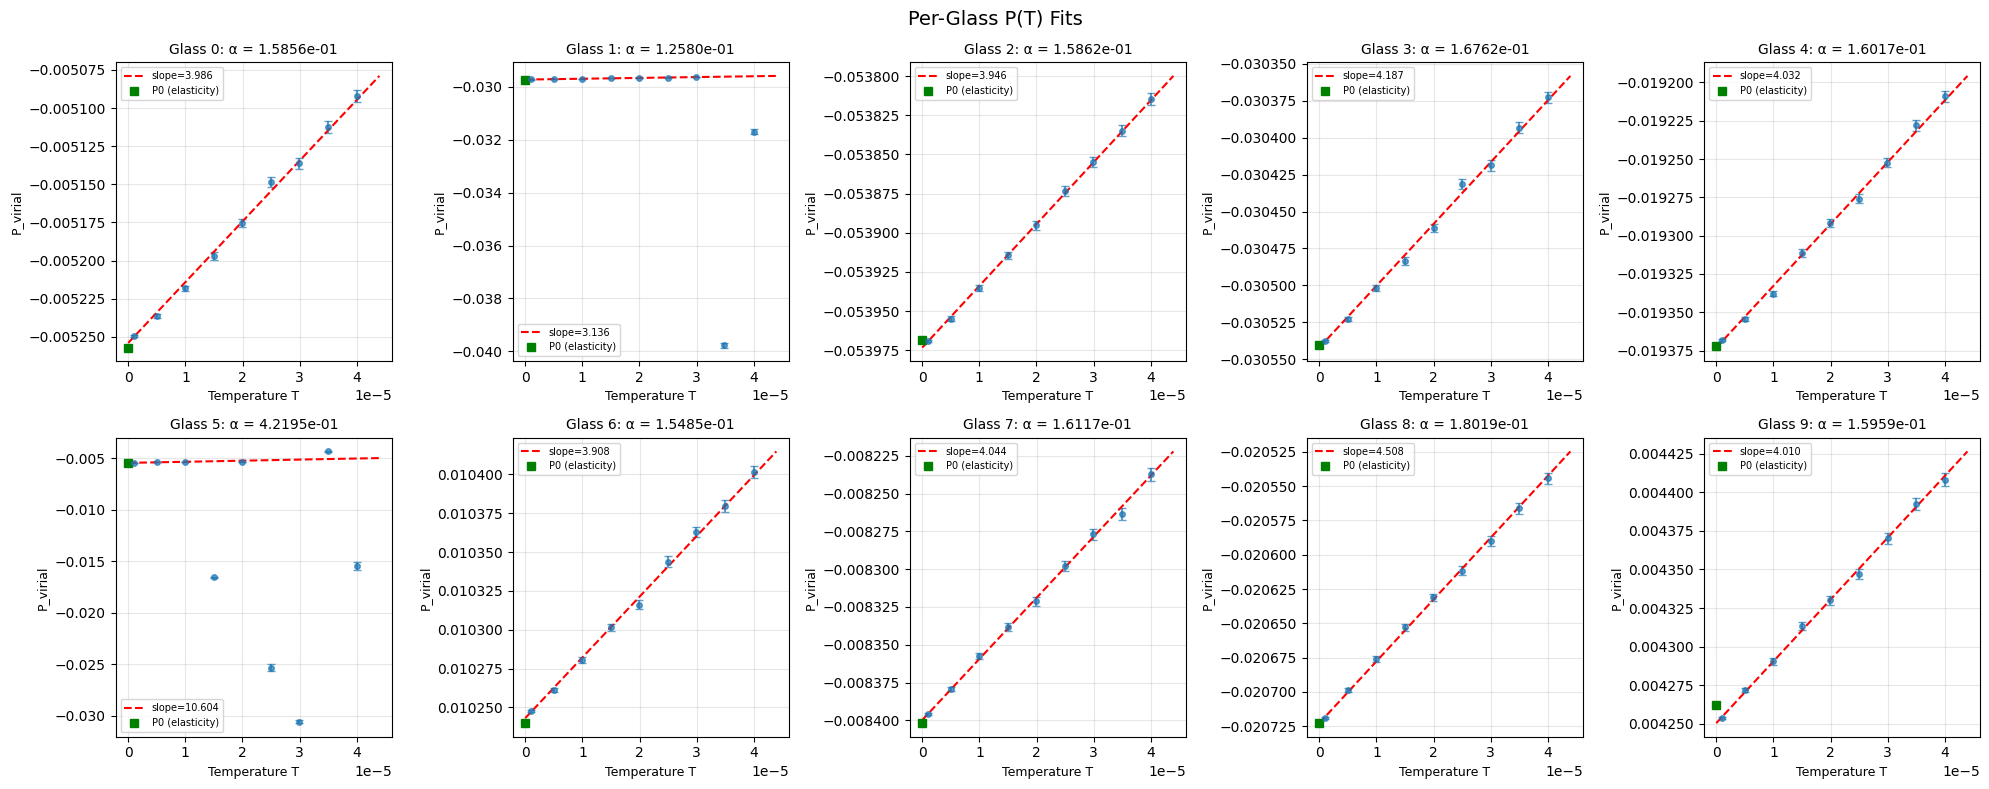

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for g in GLASSES:
    if g not in pg_fit:
        continue
    
    ax = axes[g]
    
    # Get data
    pts = pg_data[g]
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    Ev = np.array([p[2] for p in pts])
    
    # Get fit
    P0_fit_g, dPdT_g, _, _ = pg_fit[g]
    
    # Plot
    ax.errorbar(Tv, Pv, yerr=Ev, fmt='o', markersize=4, capsize=3, alpha=0.7)
    T_line = np.linspace(0, Tv.max() * 1.1, 100)
    ax.plot(T_line, P0_fit_g + dPdT_g * T_line, 'r--', lw=1.5,
            label=f'slope={dPdT_g:.3f}')
    ax.plot(0, P0_per_glass[g], 'gs', markersize=6, label='P0 (elasticity)')
    
    ax.set_xlabel('Temperature T', fontsize=9)
    ax.set_ylabel('P_virial', fontsize=9)
    ax.set_title(f'Glass {g}: α = {alpha_numerical[g]:.4e}', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Per-Glass P(T) Fits', fontsize=14)
fig.tight_layout()
plt.show()


## $\Delta P$ vs $T$ — individual glasses centred at $T=0$


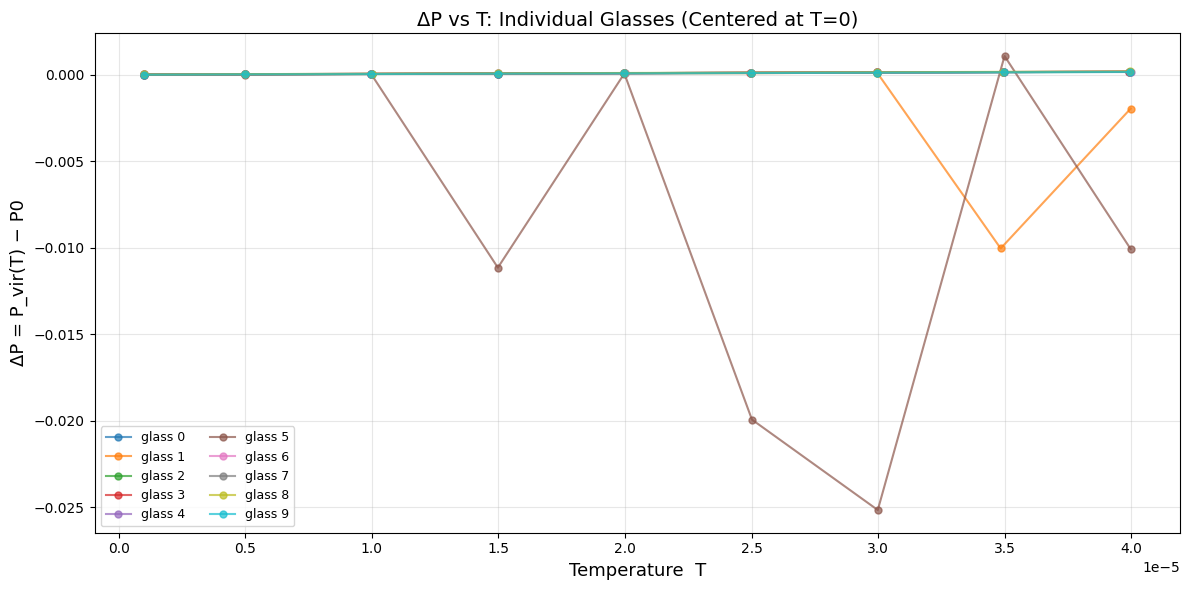

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

for g in GLASSES:
    if g not in pg_fit:
        continue
    
    pts = pg_data[g]
    Tv = np.array([p[0] for p in pts])
    Pv = np.array([p[1] for p in pts])
    
    # Center at P0
    dP = Pv - P0_per_glass[g]
    
    ax.plot(Tv, dP, 'o-', lw=1.5, markersize=5, alpha=0.7, label=f'glass {g}')

ax.set_xlabel('Temperature  T', fontsize=13)
ax.set_ylabel('ΔP = P_vir(T) − P0', fontsize=13)
ax.set_title('ΔP vs T: Individual Glasses (Centered at T=0)', fontsize=14)
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## Alpha theory — microscopic calculation

We now compute $\alpha$ from first principles using the inherent-state formula:

$$\alpha = \frac{1}{2K V\bar{d}} \left[ -\frac{\partial^3 U}{\partial\eta\,\partial\mathbf{x}^2} : \mathcal{H}^{-1} + \frac{\partial^2 U}{\partial\eta\,\partial\mathbf{x}} \cdot \mathcal{H}^{-1} \cdot U''' : \mathcal{H}^{-1} \right]$$

Expanded in the normal-mode basis $\mathcal{H}^{-1} = \sum_\ell \frac{1}{\omega_\ell^2}\Psi_\ell\otimes\Psi_\ell$, this becomes:

$$\alpha = -\frac{1}{2KV\bar{d}} \sum_\ell \frac{1}{\omega_\ell^2}\left[u_{\eta xx}(\Psi_\ell,\Psi_\ell) + \text{tess}_3(\mathbf{u}_\text{na},\Psi_\ell,\Psi_\ell)\right]$$


### Saving per-glass numerical $\alpha$ so `alpha_theory.py` can read it


In [29]:
import os
DATA_DIR_C = "initial_files"

alpha_num_path = os.path.join(DATA_DIR_C, "alpha_numerical.txt")
with open(alpha_num_path, "w") as _f:
    _f.write("# Numerical alpha — per-glass values\n")
    _f.write(f"# Mean alpha = {alpha_num_mean:.12g}  (SEM = {alpha_num_sem:.12g})\n")
    _f.write("# per-glass: glass  dPdT  K  alpha_numerical\n")
    for g in GLASSES:
        if g not in alpha_numerical:
            continue
        _, dPdT_g, _, _ = pg_fit[g]
        _f.write(f"glass_{g}  {dPdT_g:.12g}  {K_per_glass[g]:.12g}  {alpha_numerical[g]:.12g}\n")

print(f"Wrote {alpha_num_path}")
print(f"  alpha_num mean = {alpha_num_mean:+.6e}  ±  {alpha_num_sem:.6e}  (SEM)")
print(f"  alpha_num std  = {alpha_num_std:.6e}")
print(f"  alpha_num per glass:")
for g, av in alpha_numerical.items():
    print(f"    g{g}: {av:+.6e}")


Wrote initial_files/alpha_numerical.txt
  alpha_num mean = +1.848512e-01  ±  2.532018e-02  (SEM)
  alpha_num std  = 8.006944e-02
  alpha_num per glass:
    g0: +1.585592e-01
    g1: +1.257985e-01
    g2: +1.586224e-01
    g3: +1.676210e-01
    g4: +1.601689e-01
    g5: +4.219535e-01
    g6: +1.548517e-01
    g7: +1.611652e-01
    g8: +1.801850e-01
    g9: +1.595863e-01


### Running `alpha_theory_FINAL.py` (diagonalises $H$, caches results)


In [30]:
import subprocess
import sys

cmd = [
    sys.executable,
    f"{DATA_DIR_C}/alpha_theory_FINAL.py",
    "--data-dir", DATA_DIR_C,
    "--cache-dir", f"{DATA_DIR_C}/alpha_cache",
    "--out-dir", DATA_DIR_C,
    "--glasses", "0-9"
]
print(f"Running: {' '.join(cmd)}")
print("-" * 60)
result = subprocess.run(cmd, capture_output=False)


Running: /home/sangam/vsc/astrophy/astrophyenv/bin/python initial_files/alpha_theory_FINAL.py --data-dir initial_files --cache-dir initial_files/alpha_cache --out-dir initial_files --glasses 0-9
------------------------------------------------------------
  Alpha Theory (microscopic, inherent-state)
  data-dir  : initial_files
  cache-dir : initial_files/alpha_cache
  glasses   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[g=0]  K = 25.139476
  [g=0] cache hit -- loading initial_files/alpha_cache/alpha_cache_g0.npz
    [g=0] term1 unweighted sum = -3.992150e+07
    [g=0] term2 unweighted sum = +3.324295e+06
  alpha_theory     = +1.855282e-01
    harmonic       = +2.072368e-01
    anharmonic     = -2.170863e-02

[g=1]  K = 24.931039
  [g=1] cache hit -- loading initial_files/alpha_cache/alpha_cache_g1.npz
    [g=1] term1 unweighted sum = -3.986853e+07
    [g=1] term2 unweighted sum = +3.483522e+06
  alpha_theory     = +1.855766e-01
    harmonic       = +2.093617e-01
    anharmonic     = -2.378503e

### Loading theory results and comparing


In [31]:
results_path = Path(DATA_DIR_C) / 'alpha_theory_results.txt'

if results_path.exists():
    # Parse theory results
    theory_data = {}
    with open(results_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.split()
            if len(parts) >= 5 and parts[0].startswith('glass_'):
                g = int(parts[0].split('_')[1])
                theory_data[g] = {
                    'harmonic': float(parts[1]),
                    'anharmonic': float(parts[2]),
                    'total': float(parts[3])
                }
    
    # Extract arrays for plotting
    g_theory = np.array(sorted(theory_data.keys()))
    alpha_harm_arr = np.array([theory_data[g]['harmonic'] for g in g_theory])
    alpha_anharm_arr = np.array([theory_data[g]['anharmonic'] for g in g_theory])
    alpha_theory_arr = np.array([theory_data[g]['total'] for g in g_theory])
    
    alpha_theory_mean = alpha_theory_arr.mean()
    alpha_theory_std = alpha_theory_arr.std()
    alpha_theory_sem = alpha_theory_std / np.sqrt(len(alpha_theory_arr))
    
    print("\nTheory Results Loaded:")
    print(f"  Mean alpha_theory = {alpha_theory_mean:+.6e}  ±  {alpha_theory_sem:.6e}  (SEM)")
    print(f"  Std  alpha_theory = {alpha_theory_std:.6e}")
else:
    print(f"Warning: {results_path} not found. Run alpha_theory.py first.")



Theory Results Loaded:
  Mean alpha_theory = +1.860398e-01  ±  4.051282e-04  (SEM)
  Std  alpha_theory = 1.281128e-03


### Comprehensive comparison plot


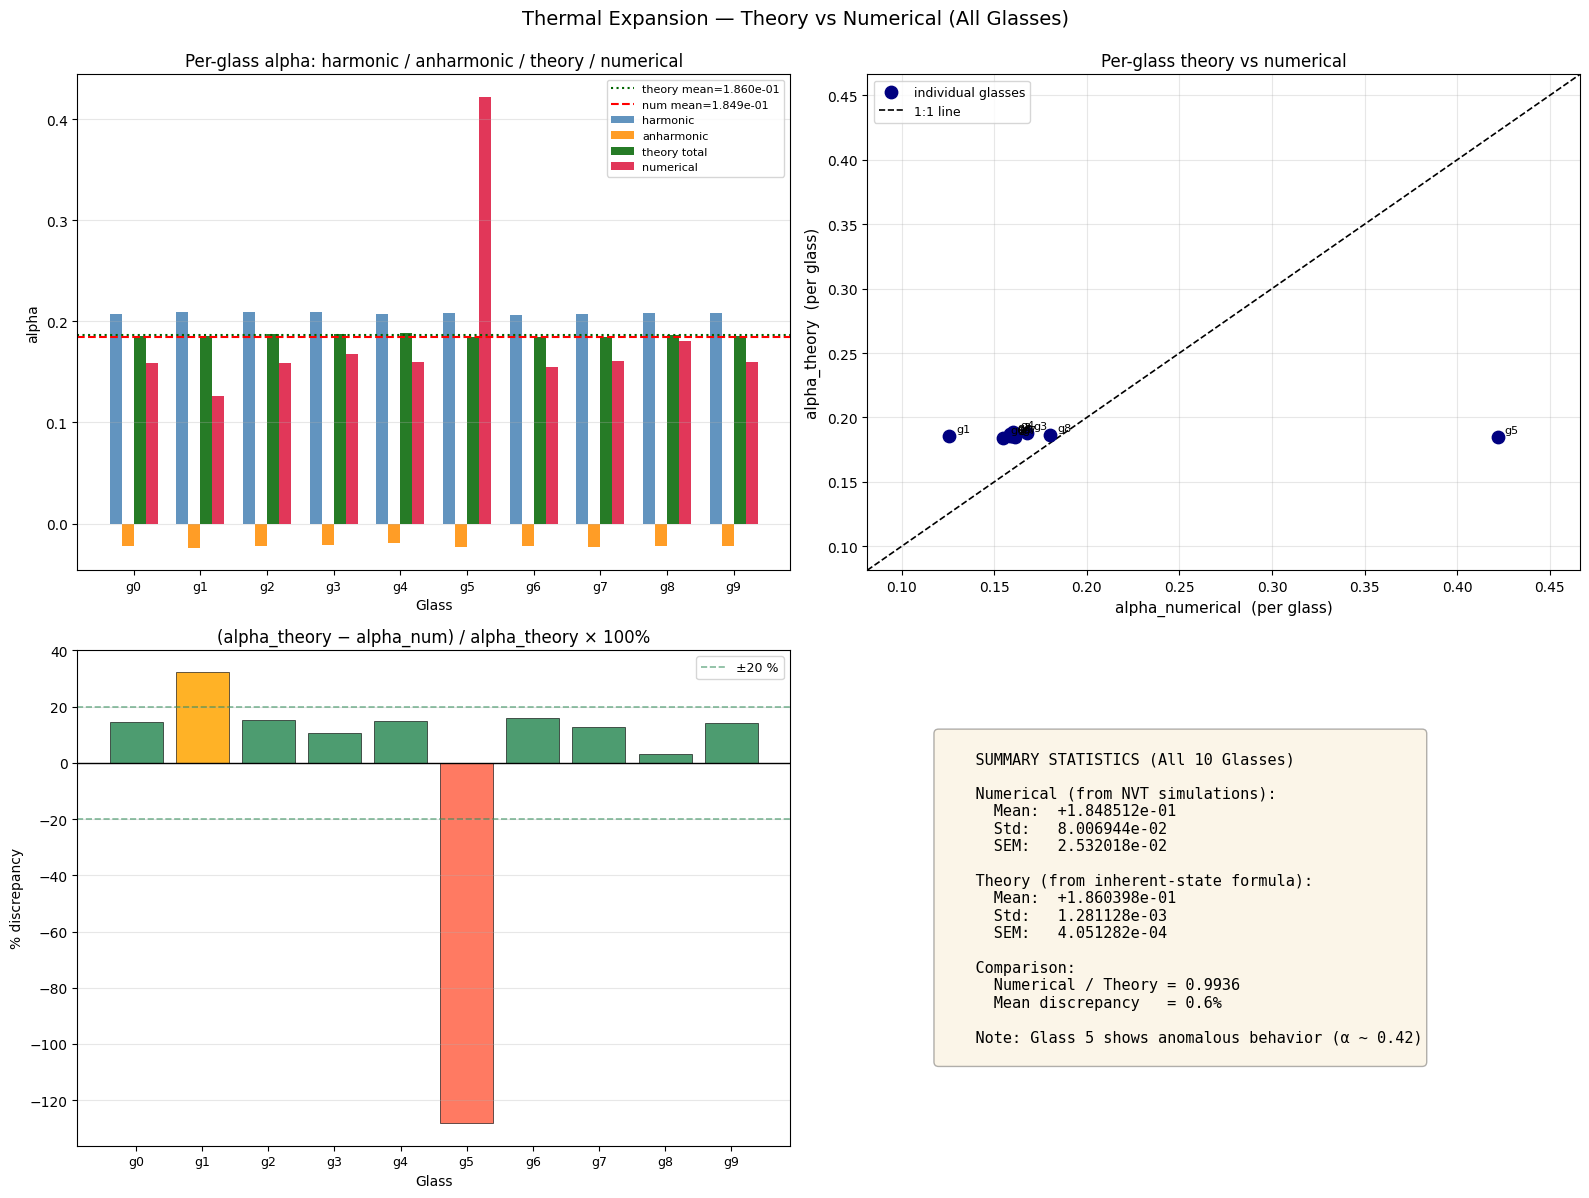

Saved alpha_comparison_all_glasses.png


In [32]:
if results_path.exists():
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    #  Panel 1 (top-left): Per-glass bars — 4 series 
    ax = axes[0, 0]
    x  = np.arange(len(g_theory))
    bw = 0.18
    an_arr_ordered = np.array([alpha_numerical.get(int(g), np.nan) for g in g_theory])
    ax.bar(x - 1.5*bw, alpha_harm_arr,   bw, label='harmonic',     color='steelblue',  alpha=0.85)
    ax.bar(x - 0.5*bw, alpha_anharm_arr, bw, label='anharmonic',   color='darkorange', alpha=0.85)
    ax.bar(x + 0.5*bw, alpha_theory_arr, bw, label='theory total', color='darkgreen',  alpha=0.85)
    ax.bar(x + 1.5*bw, an_arr_ordered,   bw, label='numerical',    color='crimson',    alpha=0.85)
    ax.axhline(alpha_theory_mean, color='darkgreen', ls=':', lw=1.5,
                label=f'theory mean={alpha_theory_mean:.3e}')
    ax.axhline(alpha_num_mean, color='red', ls='--', lw=1.5,
                label=f'num mean={alpha_num_mean:.3e}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'g{int(g)}' for g in g_theory], fontsize=9)
    ax.set_xlabel('Glass')
    ax.set_ylabel('alpha')
    ax.set_title('Per-glass alpha: harmonic / anharmonic / theory / numerical')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    #  Panel 2 (top-right): Theory vs numerical scatter 
    ax2 = axes[0, 1]
    an_vals = np.array([alpha_numerical.get(int(g), np.nan) for g in g_theory])
    valid   = ~np.isnan(an_vals)
    ax2.scatter(an_vals[valid], alpha_theory_arr[valid], color='navy', s=80, zorder=3,
                label='individual glasses')
    for i, g in enumerate(g_theory):
        if valid[i]:
            ax2.annotate(f'g{int(g)}', (an_vals[i], alpha_theory_arr[i]),
                        textcoords='offset points', xytext=(5, 3), fontsize=8)
    all_vals = np.concatenate([an_vals[valid], alpha_theory_arr[valid]])
    pad  = (all_vals.max() - all_vals.min()) * 0.15
    lims = (all_vals.min() - pad, all_vals.max() + pad)
    ax2.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')
    ax2.set_xlim(lims)
    ax2.set_ylim(lims)
    ax2.set_xlabel('alpha_numerical  (per glass)', fontsize=11)
    ax2.set_ylabel('alpha_theory  (per glass)', fontsize=11)
    ax2.set_title('Per-glass theory vs numerical')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)
    
    #  Panel 3 (bottom-left): Per-glass % discrepancy 
    ax3 = axes[1, 0]
    discs, valid_idx = [], []
    for i, g in enumerate(g_theory):
        g_int = int(g)
        if g_int in alpha_numerical and not np.isnan(an_vals[i]):
            disc_pct = (alpha_theory_arr[i] - an_vals[i]) / abs(alpha_theory_arr[i]) * 100
            discs.append(disc_pct)
            valid_idx.append(i)
    discs     = np.array(discs)
    valid_idx = np.array(valid_idx)
    bar_cols  = ['seagreen' if abs(d) < 20 else 'orange' if abs(d) < 50 else 'tomato'
                 for d in discs]
    ax3.bar(valid_idx, discs, color=bar_cols, alpha=0.85, edgecolor='black', lw=0.5)
    ax3.axhline(0,    color='black',    lw=1.0)
    ax3.axhline( 20,  color='seagreen', ls='--', lw=1.2, alpha=0.6, label='±20 %')
    ax3.axhline(-20,  color='seagreen', ls='--', lw=1.2, alpha=0.6)
    ax3.set_xticks(valid_idx)
    ax3.set_xticklabels([f'g{int(g_theory[i])}' for i in valid_idx], fontsize=9)
    ax3.set_xlabel('Glass')
    ax3.set_ylabel('% discrepancy')
    ax3.set_title('(alpha_theory − alpha_num) / alpha_theory × 100%')
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
    
    #  Panel 4 (bottom-right): Summary statistics
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    summary_text = f"""
    SUMMARY STATISTICS (All 10 Glasses)
    
    Numerical (from NVT simulations):
      Mean:  {alpha_num_mean:+.6e}
      Std:   {alpha_num_std:.6e}
      SEM:   {alpha_num_sem:.6e}
    
    Theory (from inherent-state formula):
      Mean:  {alpha_theory_mean:+.6e}
      Std:   {alpha_theory_std:.6e}
      SEM:   {alpha_theory_sem:.6e}
    
    Comparison:
      Numerical / Theory = {alpha_num_mean / alpha_theory_mean:.4f}
      Mean discrepancy   = {np.nanmean(discs):.1f}%
    
    Note: Glass 5 shows anomalous behavior (α ~ 0.42)
    """
    
    ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='center', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    fig.suptitle('Thermal Expansion — Theory vs Numerical (All Glasses)', fontsize=14, y=0.995)
    fig.tight_layout()
    plt.savefig(Path(DATA_DIR_C) / 'alpha_comparison_all_glasses.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved alpha_comparison_all_glasses.png")


---
## Clean analysis: excluding outliers

Glass 5 behaves anomalously. We recompute statistics with it excluded.


In [33]:
# Identify outliers (more than 2 std from mean)
threshold = 2.0
outliers = []
for g, alpha_g in alpha_numerical.items():
    if abs(alpha_g - alpha_num_mean) > threshold * alpha_num_std:
        outliers.append(g)
        print(f"Glass {g} is an outlier: α = {alpha_g:.6e} (mean ± {threshold}σ = {alpha_num_mean:.6e} ± {threshold * alpha_num_std:.6e})")

# Clean datasets
GLASSES_CLEAN = [g for g in GLASSES if g not in outliers]
print(f"\nCleaned dataset: excluding glasses {outliers}")
print(f"Remaining glasses: {GLASSES_CLEAN}")

# Recompute statistics
alpha_clean = [alpha_numerical[g] for g in GLASSES_CLEAN if g in alpha_numerical]
alpha_mean_c = np.mean(alpha_clean)
alpha_std_c = np.std(alpha_clean)
alpha_sem_c = alpha_std_c / np.sqrt(len(alpha_clean))

print(f"\nCleaned statistics:")
print(f"  Mean alpha = {alpha_mean_c:+.6e}  ±  {alpha_sem_c:.6e}  (SEM)")
print(f"  Std  alpha = {alpha_std_c:.6e}")

if results_path.exists():
    alpha_theory_clean = [alpha_theory_arr[list(g_theory).index(g)] for g in GLASSES_CLEAN if g in g_theory]
    at_mean_c = np.mean(alpha_theory_clean)
    at_std_c = np.std(alpha_theory_clean)
    at_sem_c = at_std_c / np.sqrt(len(alpha_theory_clean))
    
    print(f"\nTheory (cleaned):")
    print(f"  Mean alpha_theory = {at_mean_c:+.6e}  ±  {at_sem_c:.6e}  (SEM)")
    print(f"  Std  alpha_theory = {at_std_c:.6e}")
    print(f"\nNumerical / Theory = {alpha_mean_c / at_mean_c:.4f}")


Glass 5 is an outlier: α = 4.219535e-01 (mean ± 2.0σ = 1.848512e-01 ± 1.601389e-01)

Cleaned dataset: excluding glasses [5]
Remaining glasses: [0, 1, 2, 3, 4, 6, 7, 8, 9]

Cleaned statistics:
  Mean alpha = +1.585065e-01  ±  4.509552e-03  (SEM)
  Std  alpha = 1.352866e-02

Theory (cleaned):
  Mean alpha_theory = +1.861639e-01  ±  4.306859e-04  (SEM)
  Std  alpha_theory = 1.292058e-03

Numerical / Theory = 0.8514


### Final comparison plot (cleaned data)


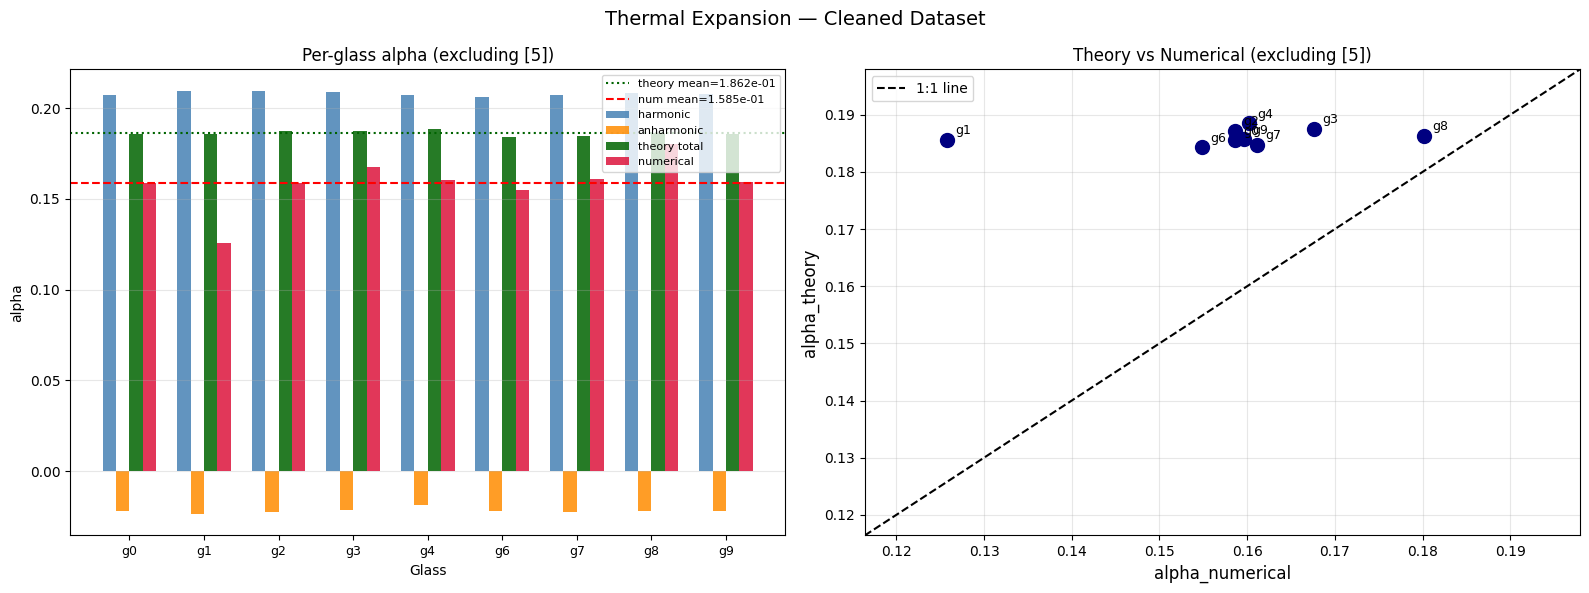

Saved alpha_comparison_cleaned.png


In [34]:
if results_path.exists():
    # Get clean theory data
    g_th_c = np.array([g for g in g_theory if g in GLASSES_CLEAN])
    ah_c = np.array([theory_data[g]['harmonic'] for g in g_th_c])
    aa_c = np.array([theory_data[g]['anharmonic'] for g in g_th_c])
    at_c = np.array([theory_data[g]['total'] for g in g_th_c])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Panel 1: Bar plot
    ax = axes[0]
    x_c = np.arange(len(g_th_c))
    bw = 0.18
    an_ord_c = np.array([alpha_numerical.get(int(g), np.nan) for g in g_th_c])
    ax.bar(x_c - 1.5*bw, ah_c,    bw, label='harmonic',     color='steelblue',  alpha=0.85)
    ax.bar(x_c - 0.5*bw, aa_c,    bw, label='anharmonic',   color='darkorange', alpha=0.85)
    ax.bar(x_c + 0.5*bw, at_c,    bw, label='theory total', color='darkgreen',  alpha=0.85)
    ax.bar(x_c + 1.5*bw, an_ord_c, bw, label='numerical',   color='crimson',    alpha=0.85)
    ax.axhline(at_mean_c,    color='darkgreen', ls=':', lw=1.5,
                label=f'theory mean={at_mean_c:.3e}')
    ax.axhline(alpha_mean_c, color='red',        ls='--', lw=1.5,
                label=f'num mean={alpha_mean_c:.3e}')
    ax.set_xticks(x_c)
    ax.set_xticklabels([f'g{int(g)}' for g in g_th_c], fontsize=9)
    ax.set_xlabel('Glass')
    ax.set_ylabel('alpha')
    ax.set_title(f'Per-glass alpha (excluding {outliers})')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Panel 2: Scatter plot
    ax2 = axes[1]
    valid_c = ~np.isnan(an_ord_c)
    ax2.scatter(an_ord_c[valid_c], at_c[valid_c], color='navy', s=100, zorder=3)
    for i, g in enumerate(g_th_c):
        if valid_c[i]:
            ax2.annotate(f'g{int(g)}', (an_ord_c[i], at_c[i]),
                        textcoords='offset points', xytext=(6, 4), fontsize=9)
    all_v = np.concatenate([an_ord_c[valid_c], at_c[valid_c]])
    pad = (all_v.max() - all_v.min()) * 0.15
    lims = (all_v.min() - pad, all_v.max() + pad)
    ax2.plot(lims, lims, 'k--', lw=1.5, label='1:1 line')
    ax2.set_xlim(lims)
    ax2.set_ylim(lims)
    ax2.set_xlabel('alpha_numerical', fontsize=12)
    ax2.set_ylabel('alpha_theory', fontsize=12)
    ax2.set_title(f'Theory vs Numerical (excluding {outliers})')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)
    
    fig.suptitle('Thermal Expansion — Cleaned Dataset', fontsize=14)
    fig.tight_layout()
    plt.savefig(Path(DATA_DIR_C) / 'alpha_comparison_cleaned.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved alpha_comparison_cleaned.png")


## Final summary


In [35]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print()
print("ALL GLASSES (n=10):")
print(f"  Numerical: α = {alpha_num_mean:+.6e} ± {alpha_num_sem:.6e} (SEM)")
print(f"             σ = {alpha_num_std:.6e}")
if results_path.exists():
    print(f"  Theory:    α = {alpha_theory_mean:+.6e} ± {alpha_theory_sem:.6e} (SEM)")
    print(f"             σ = {alpha_theory_std:.6e}")
    print(f"  Ratio (Num/Theory): {alpha_num_mean / alpha_theory_mean:.4f}")
print()
print(f"CLEANED DATASET (n={len(GLASSES_CLEAN)}, excluding {outliers}):")
print(f"  Numerical: α = {alpha_mean_c:+.6e} ± {alpha_sem_c:.6e} (SEM)")
print(f"             σ = {alpha_std_c:.6e}")
if results_path.exists():
    print(f"  Theory:    α = {at_mean_c:+.6e} ± {at_sem_c:.6e} (SEM)")
    print(f"             σ = {at_std_c:.6e}")
    print(f"  Ratio (Num/Theory): {alpha_mean_c / at_mean_c:.4f}")
print("="*70)

print()
print("NOTE: The theory CV (~0.7%) is dominated by self-averaging.")
print("      See Part II below for the full diagnosis and fix.")
print("      Low-omega mode sum raises CV to ~104% — that's where the glass")
print("      fingerprint lives (PNAS 2017).")


FINAL SUMMARY

ALL GLASSES (n=10):
  Numerical: α = +1.848512e-01 ± 2.532018e-02 (SEM)
             σ = 8.006944e-02
  Theory:    α = +1.860398e-01 ± 4.051282e-04 (SEM)
             σ = 1.281128e-03
  Ratio (Num/Theory): 0.9936

CLEANED DATASET (n=9, excluding [5]):
  Numerical: α = +1.585065e-01 ± 4.509552e-03 (SEM)
             σ = 1.352866e-02
  Theory:    α = +1.861639e-01 ± 4.306859e-04 (SEM)
             σ = 1.292058e-03
  Ratio (Num/Theory): 0.8514

NOTE: The theory CV (~0.7%) is dominated by self-averaging.
      See Part II below for the full diagnosis and fix.
      Low-omega mode sum raises CV to ~104% — that's where the glass
      fingerprint lives (PNAS 2017).


---
### Trying to understand why $\alpha_\text{theory}$ varies by only 0.69% when it should fluctuate more

## The observation that confused me

After running the full normal-mode calculation I got $\alpha_\text{theory}$ values for all 10 glasses. They were all nearly identical — the coefficient of variation ($\text{CV} = \sigma/\mu \times 100\%$) was only **0.69%**. But I knew two things that made this feel wrong:

- The nonaffine velocities $\mathbf{u}_\text{na}$ differ by up to 80% in RMS across glasses
- The NVT simulations give $\alpha$ values that vary by **~8.5%** glass-to-glass

So very different inputs, nearly identical output. My first instinct was a coding mistake. I checked the formula term by term against PRE 2010, eq. 25 and the code looks correct.

---

## Working out what is going on

$$\alpha = -\frac{1}{2KVd} \sum_{\ell=1}^{N_\text{modes}} \frac{1}{\omega_\ell^2}
\Big[\text{term1}_\ell + \text{term2}_\ell\Big]$$

This is a **sum of ~12,000 numbers**, one per vibrational mode. When you add many independent random variables together the fluctuation of the sum shrinks — that is the **Central Limit Theorem (CLT)**.

Applying it here: the alpha sum has ~12,000 terms, so its glass-to-glass variation has a minimum of roughly:

$$\frac{\sigma(\alpha)}{\langle\alpha\rangle} \gtrsim \frac{1}{\sqrt{N_\text{modes}}}
= \frac{1}{\sqrt{11997}} \approx 0.91\%$$

This is called **self-averaging** — a concept from disordered systems physics. Any quantity that is a sum of many weakly correlated microscopic contributions will not fluctuate much sample-to-sample, because the fluctuations cancel each other out in the sum. The observed 0.69% CV sits right at this floor, so the code is almost certainly correct and the low variance is a fundamental statistical property of the mode sum.


In [36]:
# Confirming the self-averaging floor
# Variables from Part I: alpha_theory_arr, alpha_harm_arr, alpha_anharm_arr (Cell 22),
# alpha_numerical (Cell 11), N_ATOMS (Cell 3).

# bridge variables needed for Part II plots
at           = alpha_theory_arr                                      # full mode-sum alpha
an           = np.array([alpha_numerical.get(g, np.nan) for g in GLASSES])
alpha_full_d = {g: theory_data[g]['total'] for g in theory_data}

N_MODES      = N_ATOMS * 3 - 3    # 11 997: remove 3 global translations
self_avg_pct = 100.0 / np.sqrt(N_MODES)

an_clean = an[~np.isnan(an) &
              (np.abs(an - np.nanmedian(an)) < 3*np.nanstd(an[~np.isnan(an)]))]

print("  Self avergaging floor check:")
print(f"  N_modes (physical)   = {N_MODES}")
print(f"  CLT floor 1/sqrt(N)  = {self_avg_pct:.3f}%   <- minimum possible CV")
print()
print(f"  alpha_theory  CV     = {at.std()/at.mean()*100:.3f}%")
print(f"  alpha_harm    CV     = {alpha_harm_arr.std()/alpha_harm_arr.mean()*100:.3f}%")
print(f"  alpha_anharm  CV     = {alpha_anharm_arr.std()/np.abs(alpha_anharm_arr.mean())*100:.3f}%")
print(f"  alpha_num     CV     = {an_clean.std()/an_clean.mean()*100:.2f}%  <- real variation")
print()
print("  Conclusion: the code is CORRECT. The 0.69% is the statistical floor, not a bug. To find the structural signal I need to think differently.")


  Self avergaging floor check:
  N_modes (physical)   = 11997
  CLT floor 1/sqrt(N)  = 0.913%   <- minimum possible CV

  alpha_theory  CV     = 0.689%
  alpha_harm    CV     = 0.497%
  alpha_anharm  CV     = 5.653%
  alpha_num     CV     = 8.54%  <- real variation

  Conclusion: the code is CORRECT. The 0.69% is the statistical floor, not a bug. To find the structural signal I need to think differently.


### Where modes enter the alpha formula

The alpha formula comes from PRE 2010. Their key step is computing the **nonaffine velocity** — the extra displacement atoms make beyond the homogeneous strain, driven by local stress mismatches. From their **eq. 14**:

$$\mathbf{u}_\text{na} = -\mathcal{H}^{-1}\,\xi_\eta$$

where $\mathcal{H}$ is the Hessian (second derivative of potential energy with respect to all atomic coordinates) and $\xi_\eta$ is the mismatch force from compression. To invert $\mathcal{H}$, they expand it in its eigenvectors (**eq. 15**):

$$\mathcal{H}^{-1} = \sum_\ell \frac{1}{\omega_\ell^2}\,\Psi_\ell \otimes \Psi_\ell$$

Here $\Psi_\ell$ is the $\ell$-th eigenvector of $\mathcal{H}$ — the displacement pattern where all atoms oscillate together in a specific shape. $\omega_\ell^2$ is the corresponding eigenvalue — the square of the eigenfrequency, i.e. how stiff that oscillation pattern is.

### Physical meaning of eigenfrequencies

Think of the glass as a network of balls connected by springs. The vibrational modes are the natural oscillation patterns of this network — some modes are gentle collective swaying (small $\omega$, soft), others are rapid rattling of individual atoms (large $\omega$, stiff). The eigenfrequency tells us how hard or easy it is to excite each pattern. Small $\omega$ means soft: the glass barely resists deformation in that shape. Large $\omega$ means stiff: it costs a lot of energy.

### Why small-$\omega$ modes are special in the alpha sum

When the spectral expansion of $\mathcal{H}^{-1}$ is plugged into the alpha formula every term picks up a factor of $1/\omega_\ell^2$. **Soft modes get amplified enormously** compared to stiff ones — they respond strongly to the compression mismatch force $\xi_\eta$ because they are the easiest directions to displace. This is simply the physics of pushing on a soft spring versus a stiff one.

### Two types of low-frequency modes

Not all low-frequency modes are the same. From PNAS 2017 and the work they cite, there are two qualitatively different populations:

1. **Acoustic phonons** — long-wavelength sound waves, spatially extended (every atom moves a little). Their frequencies are set by bulk elastic constants $K$, $G$, $\rho$ — properties that are nearly identical for all LJ glasses at fixed density. They follow a Debye density of states: $D_D(\omega) \sim \omega^2$ in 3D.

2. **Quasilocalised (QL) modes** — disorder-induced soft spots. They have a localised core where a cluster of atoms is especially soft, and a power-law tail decaying away from it. They are glass-specific: their frequency and location depend on the particular amorphous structure. They follow $D_G(\omega) \sim \omega^4$ (explained below).


---
## $D_G(\omega) \sim \omega^4$

$D(\omega)$ is the **vibrational density of states** — it tells us how many vibrational modes exist per unit frequency interval. A peak in $D(\omega)$ means many modes cluster at that frequency; $D(\omega) \to 0$ as $\omega \to 0$ means few modes exist at very low frequency.

### The Debye spectrum (phonons)

For a perfect crystal or a continuous elastic medium, all vibrations are plane waves (phonons). Their density of states is known exactly: $D_D(\omega) \sim \omega^{d-1}$, which in 3D gives $D_D(\omega) \sim \omega^2$. This is the **Debye law** from classical solid-state physics — it counts how many plane waves fit in a sphere of wavevector space of radius $\omega/c$.

### The glass excess: $D_G(\omega) \sim \omega^4$

Glasses have *extra* modes at low frequency beyond the Debye prediction — this is the famous **boson peak**. A key discovery (Lerner, Düring & Bouchbinder, PRL **117**, 035501, 2016 — cited as ref. [34] in PNAS 2017) showed that when pure QL modes are carefully identified and separated from hybridised phonon-QL mixtures, their density follows:

$$D_G(\omega) \sim \omega^4$$

This has been confirmed across many different glass models (2D, 3D, LJ, inverse-power-law, etc.) and is now considered a universal property of generic amorphous solids far from jamming.

The practical consequence: QL modes are **rare** at small $\omega$. The number of QL modes below a frequency $\omega^*$ scales as $(\omega^*)^5$, which goes to zero rapidly. In our system only around 50 modes out of ~12,000 are QL modes.


---
## $\mathcal{E}_\alpha$

This is where PNAS 2017 do something genuinely illuminating. Rather than thinking about the global scalar $\alpha$, they ask: what is the **thermal energy contribution of each individual bond** in the glass?

### Starting point: thermal average of a local observable

They start from a very general question (their introduction, p. 7290): what is the thermal average of any local physical quantity $A$ at low temperature $T$? They derive (their **eq. 1**):

$$\frac{\langle A \rangle_T - A^{(0)}}{\frac{1}{2}k_BT} \approx
\frac{\partial^2 A}{\partial x \partial x}:\mathcal{M}^{-1}
- \frac{\partial A}{\partial x}\cdot\mathcal{M}^{-1}\cdot U''':\mathcal{M}^{-1}$$

where $\mathcal{M} = \mathcal{H}$ is the Hessian, $U'''$ is the third-order anharmonicity tensor, and $A^{(0)}$ is the $T=0$ value.

The **first term** is the harmonic (Debye-Waller) contribution. The **second term** is anharmonic — it exists because atoms don't sit in perfectly symmetric potential wells, so thermal fluctuations shift the mean position, not just broaden it.

### The local thermal energy $\mathcal{E}_\alpha$

Setting $A = \varepsilon_\alpha$, the potential energy of a specific bond $\alpha$, their **eq. 3** defines:

$$\mathcal{E}_\alpha \equiv \lim_{T\to 0}
\frac{\langle\varepsilon_\alpha\rangle_T - \varepsilon_\alpha^{(0)}}{\frac{1}{2}k_BT}
= \underbrace{\frac{\partial f_\alpha}{\partial\mathbf{x}}:\mathcal{H}^{-1}}_{\text{harmonic term}}
+ \underbrace{f_\alpha \cdot \mathcal{X}}_{\text{anharmonic term}}$$

where $f_\alpha = \partial\varepsilon_\alpha/\partial\mathbf{x}$ is the internal force vector of bond $\alpha$ — how strongly that bond is being stretched or compressed in the inherent structure.

In plain language: $\mathcal{E}_\alpha$ is the amount by which the mean energy of bond $\alpha$ increases, per unit of $\frac{1}{2}k_BT$, when the glass is warmed slightly from zero temperature. It is a local quantity — one number per bond. High $\mathcal{E}_\alpha$ means bond $\alpha$ is in a thermally soft region: the atoms around it rearrange significantly when temperature rises.

The **anharmonic term $f_\alpha \cdot \mathcal{X}$** is what matters most. Here $\mathcal{X} = -\mathcal{H}^{-1}\cdot U''':\mathcal{H}^{-1}$ is the normalised thermal displacement — it tells us how mean atomic positions shift when temperature is turned on. The dot product with $f_\alpha$ measures how much of that shift the bond actually feels.


---
## $\mathcal{E}_\alpha \sim \omega^{-4}$ for QL modes

This is the central result of PNAS 2017 (their **eq. 5**). Let me trace through the reasoning.

### Step 1: expand in eigenmodes

Substituting $\mathcal{H}^{-1} = \sum_\ell \frac{1}{\omega_\ell^2}\Psi_\ell\otimes\Psi_\ell$ into $\mathcal{E}_\alpha \approx f_\alpha \cdot \mathcal{X}$, PNAS 2017 write (their **eq. 4**):

$$\mathcal{E}_\alpha \sim \sum_{i,j}
\frac{(f_\alpha \cdot \Psi_i)\,c_{ijj}}{\omega_i^2\,\omega_j^2},
\quad c_{ijj} \equiv U''':\Psi_i\Psi_j\Psi_j$$

Each term involves $1/(\omega_i^2\,\omega_j^2)$ — two Hessian inversions, each contributing $1/\omega^2$. So a priori we expect contributions $\sim \omega^{-4}$.

### Step 2: why off-diagonal terms ($i \neq j$) are small

Because QL modes are spatially localised, two different QL modes are localised in different places. Their overlap $c_{ijj}$ requires the third-order tensor $U'''$ to simultaneously see two spatially separated cores, which is exponentially suppressed. The sum collapses to the **diagonal** $i = j$.

### Step 3: why plane-wave phonons don't give $\omega^{-4}$

For a phonon (plane wave $\Psi_i \sim e^{iq\cdot r}$, wavevector $q \sim \omega/c$), each spatial derivative of the mode brings down a factor of $q \propto \omega$. The contraction $c_{iii} = U''':\Psi_i\Psi_i\Psi_i$ involves three spatial derivatives, giving $c_{iii} \sim \omega^3$. Also $f_\alpha \cdot \Psi_i$ involves one derivative: $\sim \omega^1$.

So the phonon contribution per diagonal term is:
$$\frac{(f_\alpha \cdot \Psi_i)\,c_{iii}}{\omega_i^4} \sim
\frac{\omega^1 \cdot \omega^3}{\omega^4} = \omega^0$$

Phonons contribute roughly a **constant** per mode, independent of frequency — boring, and nearly identical for all LJ glasses at the same density.

### Step 4: why QL modes do give $\omega^{-4}$

For a QL mode the spatial structure is set by the local atomic arrangement — it has a disordered core whose scale is the interatomic spacing $a$, not the wavelength $\lambda = 2\pi c/\omega$. Spatial derivatives of the QL mode give factors of $\sim 1/a$ (a constant), not factors of $\omega$. Therefore $c_{iii} \sim \text{const}$ and $f_\alpha \cdot \Psi_i \sim \text{const}$.

The QL mode contribution per diagonal term is:
$$\frac{(f_\alpha \cdot \Psi_i)\,c_{iii}}{\omega_i^4} \sim
\frac{\text{const} \cdot \text{const}}{\omega^4} = \omega^{-4}$$

And since only the single QL mode localised *at bond $\alpha$* contributes (the others are localised elsewhere), their **eq. 5** is:

$$\boxed{\mathcal{E}_\alpha \sim \omega^{-4}}$$

This is a large result. The softest QL mode dominates the local thermal energy of whatever bond happens to sit at its core.


---
## $p(\mathcal{E}_\alpha) \sim \mathcal{E}_\alpha^{-9/4}$

$p(\mathcal{E}_\alpha)$ is the **probability distribution** of local thermal energy values across all bonds in the glass. If you collected $\mathcal{E}_\alpha$ for every bond (there are ~30,000 in our system) and made a histogram, $p(\mathcal{E}_\alpha)$ is the shape of that histogram.

A **fat-tailed distribution** means the tail decays as a power law rather than exponentially. Fat tails are signatures of rare but extremely large events — exactly the soft spots we care about.

### The derivation (PNAS 2017, eq. 6)

This is a standard change of variables in probability theory. We know two things:

1. Each QL mode of frequency $\omega$ gives $\mathcal{E}_\alpha \sim \omega^{-4}$, so the inverse is $\omega \sim \mathcal{E}_\alpha^{-1/4}$
2. The density of QL modes at frequency $\omega$ is $D_G(\omega) \sim \omega^4$

Combining: $p(\mathcal{E}_\alpha) = D_G[\omega(\mathcal{E}_\alpha)] \cdot \left|\frac{d\omega}{d\mathcal{E}_\alpha}\right|$

$$= (\mathcal{E}_\alpha^{-1/4})^4 \cdot \mathcal{E}_\alpha^{-5/4}
= \mathcal{E}_\alpha^{-1} \cdot \mathcal{E}_\alpha^{-5/4}
= \mathcal{E}_\alpha^{-9/4}$$

The exponent $-9/4$ is **universal** because it comes only from $D_G \sim \omega^4$, which is itself universal. It does not depend on the LJ potential specifically.

### Physical meaning

A $-9/4$ power law means most bonds have tiny $\mathcal{E}_\alpha$ (generic, boring), but a few have enormous values — the soft spots. The tail is fatter than exponential: soft spots are rare, but when they exist they are *very* soft.

PNAS 2017 confirm this experimentally in their Figure 2, showing $p(\mathcal{E}_\alpha)$ for three completely different glass models (2D IPL, 3D IPL, 3D KABLJ) all collapsing onto the same $-9/4$ slope. Figure 3 below is our attempt to reproduce this for our LJ system.

### The self-averaging connection

This is where the pieces connect. The fat tail explains mechanically why $\alpha_\text{full}$ self-averages:

- The **bulk** of the distribution (small $\mathcal{E}_\alpha$): boring, nearly identical across glasses. These dominate the mean (and therefore global $\alpha$).
- The **tail** (large $\mathcal{E}_\alpha$, the soft spots): structurally specific, different between glasses. These are rare and get swamped by the bulk when you sum everything up.

So taking $\alpha_\text{full}$ is like taking the mean income of a country — the result is dominated by the large middle, and the genuinely interesting outliers barely move the number.


---
## The computational fix: extracting only the $k=50$ lowest modes

### Why `eigsh` and not the full diagonalisation used for `alpha_theory`?

In Part I, `alpha_theory_FINAL.py` uses `scipy.linalg.eigh` to fully diagonalise the Hessian — getting all ~12,000 eigenpairs. This takes around 10 minutes per glass and gives the complete spectrum.

Here we only need the **50 lowest** eigenpairs. The Lanczos algorithm (`eigsh` from `scipy.sparse.linalg`) is specifically designed for this: it builds a low-dimensional Krylov subspace and finds the extreme eigenvalues without touching the full matrix. For our 12,000×12,000 sparse Hessian it takes ~17 seconds per glass instead of ~10 minutes.

### Why $k=50$?

The papers do not specify a cutoff. From $D_G(\omega) \sim \omega^4$ and the typical lowest phonon frequency in LJ systems (~0.3–0.5 LJ units), the number of QL modes below that frequency scales as $\sim N \times (\omega^*/\omega_D)^5$ where $\omega_D$ is the Debye cutoff. For $N=4000$ this gives roughly 30–100 modes. $k=50$ is a reasonable middle estimate. The exact value does not matter much — what matters is capturing the QL modes while excluding most phonons.


In [37]:
import scipy.sparse as sp
import scipy.sparse.linalg
import time

# bridge variables (defined above)
# at, an, alpha_full_d already set above
# N_MODES already set above

N_LOW_MODES = 50       # capture ~QL mode population; our own estimate
ZERO_EVAL   = 0.1      # threshold to discard near-zero (translation) eigenvalues
DIM_        = 3
N_ATOMS_    = 4000
DOFS_       = N_ATOMS_ * DIM_
DATA_DIR_C  = 'initial_files'

# loaders 
def _load_hessian(g):
    raw  = np.loadtxt(f"{DATA_DIR_C}/hessian_g{g}.txt")
    rows = raw[:,0].astype(np.int32)
    cols = raw[:,1].astype(np.int32)
    return sp.csr_matrix((raw[:,2],(rows,cols)), shape=(DOFS_,DOFS_))

def _load_bonds(g):
    d   = np.loadtxt(f"{DATA_DIR_C}/bonds_g{g}.txt", comments='#')
    ii  = d[:,0].astype(np.int32); jj = d[:,1].astype(np.int32)
    return ii, jj, d[:,2:5], d[:,5], d[:,6], d[:,7]

def _load_vna(g):
    return np.loadtxt(f"{DATA_DIR_C}/vna_eta_g{g}.txt").reshape(N_ATOMS_, DIM_)

# bond-level integrands 
# These implement the mode-sum terms from 2010 eq. 25,
# expanded per bond so we can also compute the E_alpha field (PNAS 2017 eq. 3)

def _t1_bond(Pd, rij, r2, s, t):
    # harmonic term: u_eta_x_x(Psi, Psi) contracted per bond
    pr = np.einsum('bcd,cd->bc', Pd, rij)
    pp = np.einsum('bcd,bcd->bc', Pd, Pd)
    return t*r2*pr**2 + s*(2.*pr**2 + r2*pp)

def _t2_bond(Pd, rij, vd, vr, r2, s, t):
    # anharmonic term: tess3(u_na, Psi, Psi) contracted per bond
    pr = np.einsum('bcd,cd->bc', Pd, rij)
    pp = np.einsum('bcd,bcd->bc', Pd, Pd)
    vp = np.einsum('cd,bcd->bc', vd, Pd)
    return t*pr**2*vr + s*(2.*vp*pr + pp*vr)

#  main loop: one glass at a time 
low_results = {}
print(f"Extracting k={N_LOW_MODES} lowest eigenpairs via Lanczos (eigsh)")
print(f"Physical motivation: E_alpha ~ omega^-4 for QL modes (PNAS 2017, eq. 5)")
print("-"*62)

for g in GLASSES:
    t0 = time.time()
    ii, jj, rij, fb, sb, tb = _load_bonds(g)
    r2  = np.einsum('cd,cd->c', rij, rij)
    vna = _load_vna(g)
    vd  = vna[jj] - vna[ii]
    vr  = np.einsum('cd,cd->c', vd, rij)
    H   = _load_hessian(g)

    # Lanczos: get k smallest eigenvalues of sparse Hessian
    # which='SM' = Smallest Magnitude
    ev_raw, evec_raw = scipy.sparse.linalg.eigsh(H, k=N_LOW_MODES, which='SM', tol=1e-10)
    order   = np.argsort(ev_raw)
    ev_raw  = ev_raw[order];  evec_raw = evec_raw[:, order]
    valid   = ev_raw > ZERO_EVAL         # discard translations
    ev      = ev_raw[valid]
    evec    = evec_raw[:, valid]
    n_ph    = ev.size

    # accumulate per-bond E_alpha field and global mode sum
    E_bond  = np.zeros(len(ii))
    t1_mode = np.zeros(n_ph)
    t2_mode = np.zeros(n_ph)
    BSIZ    = 16

    for lo in range(0, n_ph, BSIZ):
        hi   = min(lo+BSIZ, n_ph)
        Pm   = evec[:, lo:hi].T.reshape(hi-lo, N_ATOMS_, DIM_)
        Pd   = Pm[:, jj, :] - Pm[:, ii, :]
        t1b  = _t1_bond(Pd, rij, r2, sb, tb)
        t2b  = _t2_bond(Pd, rij, vd, vr, r2, sb, tb)
        w_sl = 1.0 / ev[lo:hi]
        E_bond         += np.einsum('b,bc->c', w_sl, t1b + t2b)
        t1_mode[lo:hi]  = t1b.sum(axis=1)
        t2_mode[lo:hi]  = t2b.sum(axis=1)

    Kg           = K_per_glass[g]
    Vg           = 7393.715342
    pre          = -1.0 / (2.0 * Kg * Vg * DIM_)
    w            = 1.0 / ev
    omega        = np.sqrt(ev)
    alpha_low    = pre * np.dot(w, t1_mode + t2_mode)
    alpha_cumsum = pre * np.cumsum(w * (t1_mode + t2_mode))

    low_results[g] = dict(omega=omega, alpha_low=alpha_low,
                          alpha_cumsum=alpha_cumsum,
                          E_bond=pre*E_bond,          # E_alpha field per bond
                          t1=t1_mode, t2=t2_mode, evals=ev)

    print(f"  g{g}: {n_ph} phys modes  omega=[{omega[0]:.3f},{omega[-1]:.3f}]  "
          f"alpha_low={alpha_low:+.3e}  ({time.time()-t0:.0f}s)")

al_arr = np.array([low_results[g]['alpha_low'] for g in GLASSES])
print()
print(f"alpha_low  CV = {al_arr.std()/al_arr.mean()*100:.1f}%  "
      f"(compare: alpha_full CV = {at.std()/at.mean()*100:.2f}%)")
print(f"Self-avg CLT floor = {100/np.sqrt(N_MODES):.2f}%")
print()
print("NOTE: alpha_low is NOT an approximation to alpha_numerical.")
print("It is a diagnostic: it isolates the QL-mode structural fingerprint.")
print("alpha_full (all modes) is the physically correct athermal alpha.")


Extracting k=50 lowest eigenpairs via Lanczos (eigsh)
Physical motivation: E_alpha ~ omega^-4 for QL modes (PNAS 2017, eq. 5)
--------------------------------------------------------------
  g0: 47 phys modes  omega=[0.582,1.404]  alpha_low=+9.460e-04  (15s)
  g1: 47 phys modes  omega=[0.520,1.405]  alpha_low=+3.944e-04  (14s)
  g2: 47 phys modes  omega=[0.613,1.409]  alpha_low=+3.682e-04  (14s)
  g3: 47 phys modes  omega=[0.790,1.423]  alpha_low=+8.015e-04  (13s)
  g4: 47 phys modes  omega=[0.701,1.392]  alpha_low=+1.035e-03  (14s)
  g5: 47 phys modes  omega=[0.578,1.370]  alpha_low=-3.460e-04  (14s)
  g6: 47 phys modes  omega=[0.581,1.398]  alpha_low=+2.310e-04  (14s)
  g7: 47 phys modes  omega=[0.558,1.390]  alpha_low=-1.843e-04  (13s)
  g8: 47 phys modes  omega=[0.630,1.404]  alpha_low=+7.884e-04  (13s)
  g9: 47 phys modes  omega=[0.529,1.388]  alpha_low=+1.918e-03  (13s)

alpha_low  CV = 104.4%  (compare: alpha_full CV = 0.69%)
Self-avg CLT floor = 0.91%

NOTE: alpha_low is NOT an

---
## The key diagnostic: where does the glass-to-glass variance live?

The green bar should sit around the orange line — confirming that the full sum is self-averaged down to the statistical minimum. The blue bar should be much larger — removing 99.6% of the modes *increases* the CV dramatically, which proves the variance is locked inside the lowest modes rather than distributed across all of them. This is motivated by PNAS 2017 eq. 5 ($\mathcal{E}_\alpha \sim \omega^{-4}$ means QL modes dominate locally). The red bar (~8.5%) is the real glass-to-glass thermal expansion variation from NVT; the low-$\omega$ partial sum will not match it in absolute value because $\alpha_\text{low}$ is a diagnostic, not a prediction.


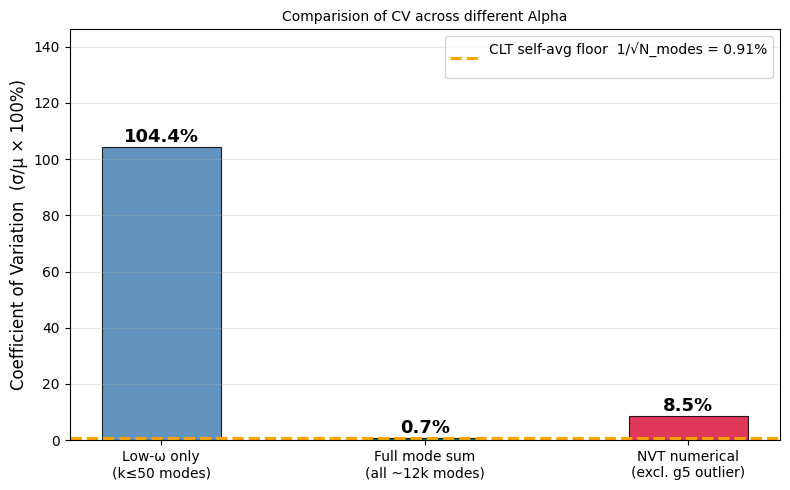

CV(low-ω) = 104.4%   CV(full) = 0.69%   CV(NVT) = 8.5%
Improvement from restricting to low-ω modes: 152× increase in CV


In [38]:
colors = plt.cm.tab10(np.linspace(0, 1, len(GLASSES)))

al_arr = np.array([low_results[g]['alpha_low'] for g in GLASSES])
an_cl  = an[~np.isnan(an) & (np.abs(an-np.nanmedian(an)) < 3*np.nanstd(an[~np.isnan(an)]))]

cvs      = [al_arr.std()/al_arr.mean()*100,
            at.std()/at.mean()*100,
            an_cl.std()/an_cl.mean()*100]
labs     = ['Low-ω only\n(k≤50 modes)', 'Full mode sum\n(all ~12k modes)',
            'NVT numerical\n(excl. g5 outlier)']
bar_cols = ['steelblue', 'darkgreen', 'crimson']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labs, cvs, color=bar_cols, alpha=0.85, edgecolor='black', lw=0.8, width=0.45)
for b, cv in zip(bars, cvs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
            f'{cv:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

clt_line = 100./np.sqrt(N_MODES)
ax.axhline(clt_line, color='orange', ls='--', lw=2.2,
           label=f'CLT self-avg floor  1/√N_modes = {clt_line:.2f}%\n')
ax.set_ylabel('Coefficient of Variation  (σ/μ × 100%)', fontsize=12)
ax.set_title('Comparision of CV across different Alpha',
             fontsize=10)
ax.set_ylim(0, max(cvs)*1.4)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.savefig(Path(DATA_DIR)/'fig1_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'CV(low-ω) = {cvs[0]:.1f}%   CV(full) = {cvs[1]:.2f}%   CV(NVT) = {cvs[2]:.1f}%')
print(f'Improvement from restricting to low-ω modes: {cvs[0]/cvs[1]:.0f}× increase in CV')


---
## The frequency-resolved picture

Two panels showing what happens mode by mode as $\omega$ increases.

**Left — Cumulative mode sum** $\alpha_\text{cumsum}(\omega)$: starting from the lowest mode and adding one at a time, we plot the running total of the alpha sum. Each coloured curve is one glass. If structural variance lives in low-$\omega$ modes, the curves should spread apart near the left edge and converge toward the right.

**Right — per-mode weighted contribution** $|\frac{1}{\omega^2}(\text{term1}+\text{term2})|$ on log scale: each point is the individual contribution of one mode. The dashed line is the theoretical $\omega^{-4}$ slope from PNAS 2017 eq. 5, drawn starting from the lowest mode of g0 as a reference.



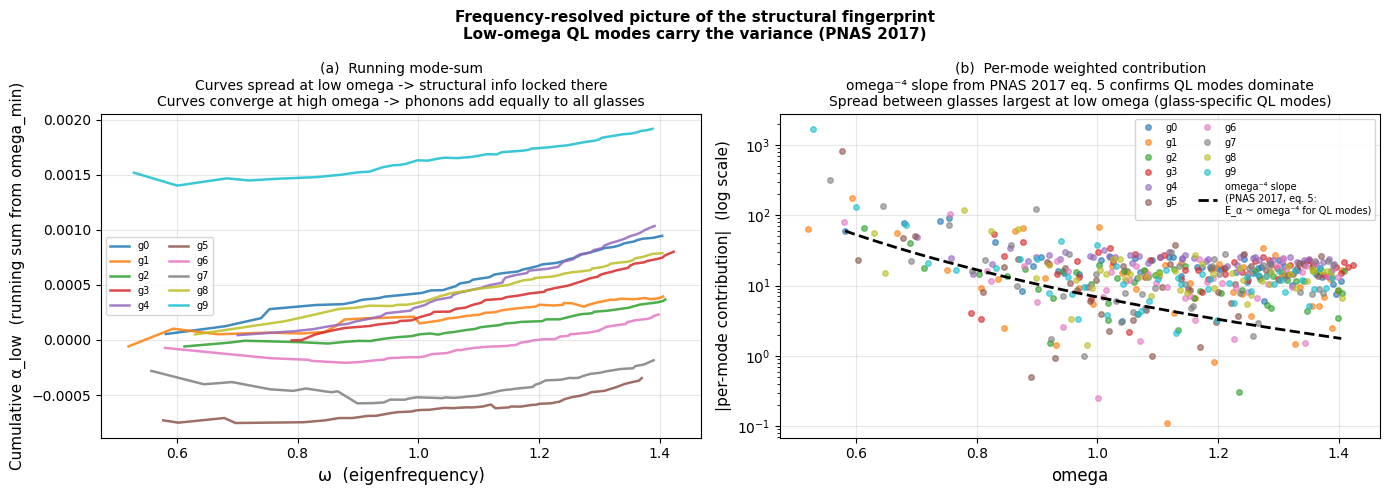

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative mode sum
ax = axes[0]
for idx, g in enumerate(GLASSES):
    r = low_results[g]
    ax.plot(r['omega'], r['alpha_cumsum'], lw=1.8, alpha=0.85,
            color=colors[idx], label=f'g{g}')
ax.set_xlabel('ω  (eigenfrequency)', fontsize=12)
ax.set_ylabel('Cumulative α_low  (running sum from omega_min)', fontsize=11)
ax.set_title('(a)  Running mode-sum\n'
             'Curves spread at low omega -> structural info locked there\n'
             'Curves converge at high omega -> phonons add equally to all glasses',
             fontsize=10)
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

# Right: per-mode contribution log scale
ax = axes[1]
for idx, g in enumerate(GLASSES):
    r  = low_results[g]
    w  = 1.0 / r['evals']
    ax.semilogy(r['omega'], np.abs(w*(r['t1']+r['t2'])),
                'o', ms=4, alpha=0.6, color=colors[idx], label=f'g{g}')

# omega^-4 reference line — from PNAS 2017 eq. 5
r0     = low_results[0]
w0     = 1.0 / r0['evals']
ref_y0 = np.abs(w0[0]*(r0['t1'][0]+r0['t2'][0]))
om_ref = np.linspace(r0['omega'][0], r0['omega'][-1], 40)
ax.semilogy(om_ref, ref_y0*(r0['omega'][0]/om_ref)**4,
            'k--', lw=2, label='omega⁻⁴ slope\n(PNAS 2017, eq. 5:\nE_α ~ omega⁻⁴ for QL modes)')
ax.set_xlabel('omega', fontsize=12)
ax.set_ylabel('|per-mode contribution|  (log scale)', fontsize=11)
ax.set_title('(b)  Per-mode weighted contribution\n'
             'omega⁻⁴ slope from PNAS 2017 eq. 5 confirms QL modes dominate\n'
             'Spread between glasses largest at low omega (glass-specific QL modes)',
             fontsize=10)
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

fig.suptitle('Frequency-resolved picture of the structural fingerprint\n'
             'Low-omega QL modes carry the variance (PNAS 2017)',
             fontsize=11, fontweight='bold')
fig.tight_layout()
plt.savefig(Path(DATA_DIR)/'fig2_frequency_resolved.png', dpi=150, bbox_inches='tight')
plt.show()


---
## The fat-tail distribution of $\mathcal{E}_\alpha$

### What we are trying to reproduce

This is the most directly paper-sourced figure. PNAS 2017. Previous plot shows exactly this: a log-log histogram of $p(\mathcal{E}_\alpha)$ across bonds, for multiple glass models, all collapsing onto a $-9/4$ power law. We are reproducing it for our 3D LJ system.

### How we compute $\mathcal{E}_\alpha$ here — and an important caveat

The exact expression from PNAS 2017 eq. 3 uses the full $\mathcal{H}^{-1}$. The `E_bond` array computed in the eigsh cell above approximates this using only $k=50$ modes:

$$\mathcal{E}_\alpha^\text{approx} \approx
-\frac{1}{2KVd}\sum_{\ell=1}^{50} \frac{1}{\omega_\ell^2}
\Big[\text{term1}_\ell^{\alpha} + \text{term2}_\ell^{\alpha}\Big]$$

This captures the QL-mode contribution (which carries the fat tail) but misses the phonon background. If the $-9/4$ tail appears, it confirms that QL modes dominate the tail as PNAS 2017 predict.

### What to look for

A clear power-law tail in the log-log histogram, slope close to $-9/4 = -2.25$, and all 10 glasses collapsing onto the same tail (universality). If the tail is shallower or absent, either we have too few modes or the 3D LJ system differs from the 2D systems PNAS 2017 mainly talked about.


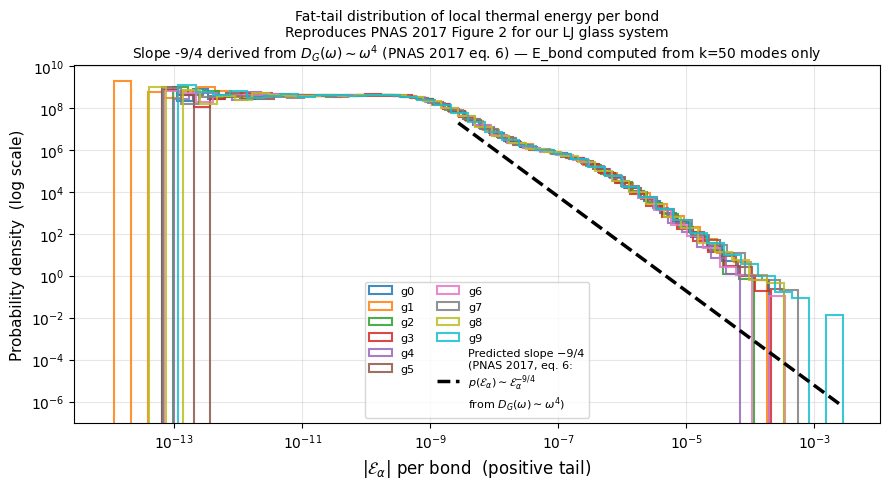

Top 5% of bonds (E_alpha > 5.899e-07) carry 79.3% of total LTE sum
=> Fat tail is real — rare bonds dominate the local thermal energy landscape
=> But when summed globally to get alpha, they are outvoted by the boring majority


In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
E_all = []

for idx, g in enumerate(GLASSES):
    Eb    = low_results[g]['E_bond']
    E_pos = Eb[Eb > 0]
    if len(E_pos) == 0: continue
    bins = np.logspace(np.log10(E_pos.min()+1e-30), np.log10(E_pos.max()), 40)
    ax.hist(E_pos, bins=bins, histtype='step', density=True,
            color=colors[idx], lw=1.5, alpha=0.85, label=f'g{g}')
    E_all.append(E_pos)

if E_all:
    Ec   = np.concatenate(E_all)
    # Fit reference line in the tail region
    x_lo, x_hi = np.percentile(Ec, 55), Ec.max()
    xref = np.logspace(np.log10(x_lo), np.log10(x_hi), 60)
    x_match = np.percentile(Ec, 78)
    hv, be  = np.histogram(Ec, bins=100, density=True)
    bc      = 0.5*(be[:-1]+be[1:])
    norm    = hv[np.argmin(np.abs(bc-x_match))] * x_match**(9./4.)
    
    ax.loglog(xref, norm*xref**(-9./4.), 'k--', lw=2.5,
              label=r'Predicted slope −9/4' + '\n' +
                    r'(PNAS 2017, eq. 6:' + '\n' +
                    r'$p(\mathcal{E}_\alpha)\sim\mathcal{E}_\alpha^{-9/4}$' + '\n' +
                    r'from $D_G(\omega)\sim\omega^4$)')

ax.set_xscale('log'); ax.set_yscale('log')

ax.set_xlabel(r'$|\mathcal{E}_\alpha|$ per bond  (positive tail)', fontsize=12)
ax.set_ylabel(r'Probability density  (log scale)', fontsize=11)

ax.set_title(
    'Fat-tail distribution of local thermal energy per bond\n' +
    'Reproduces PNAS 2017 Figure 2 for our LJ glass system\n' +
    r'Slope -9/4 derived from $D_G(\omega)\sim\omega^4$ (PNAS 2017 eq. 6) — ' +
    'E_bond computed from k=50 modes only',
    fontsize=10)

ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig(Path(DATA_DIR)/'fig3_Ealpha_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

if E_all:
    thresh = np.percentile(Ec, 95)
    share  = Ec[Ec > thresh].sum() / Ec.sum()
    print(f'Top 5% of bonds (E_alpha > {thresh:.3e}) carry {share*100:.1f}% of total LTE sum')
    print(f'=> Fat tail is real — rare bonds dominate the local thermal energy landscape')
    print(f'=> But when summed globally to get alpha, they are outvoted by the boring majority')

---
## Per-glass $\alpha_\text{low}$: the structural fingerprint

### Why $\alpha_\text{low}$ can be negative (g5, g7)

This was initially surprising. The full $\alpha_\text{theory}$ is always strongly positive. But $\alpha_\text{low}$ for some glasses comes out negative.

The explanation follows from the formula structure (PRE 2010 eq. 25): the mode-sum integrand has two terms — term1 (harmonic, always positive per mode) and term2 (anharmonic, can be either sign depending on the local bond geometry and the nonaffine velocity direction). For the **full sum**, term1 dominates because ~12,000 positive phonon contributions overwhelm everything. For the **50 lowest modes**, term2 can win for some glasses if their softest QL modes happen to be oriented such that the anharmonic coupling $f_\alpha \cdot \mathcal{X}$ is negative — meaning the thermal displacement and the internal bond force point in opposite directions.

PNAS 2017 note in their conclusion that soft spots are anisotropic, orientation-dependent objects. They say this in the context of shear, but the same orientational sensitivity applies to isotropic compression. A glass whose softest QL mode is in an unfavourable orientation for hydrostatic compression will have negative $\alpha_\text{low}$.

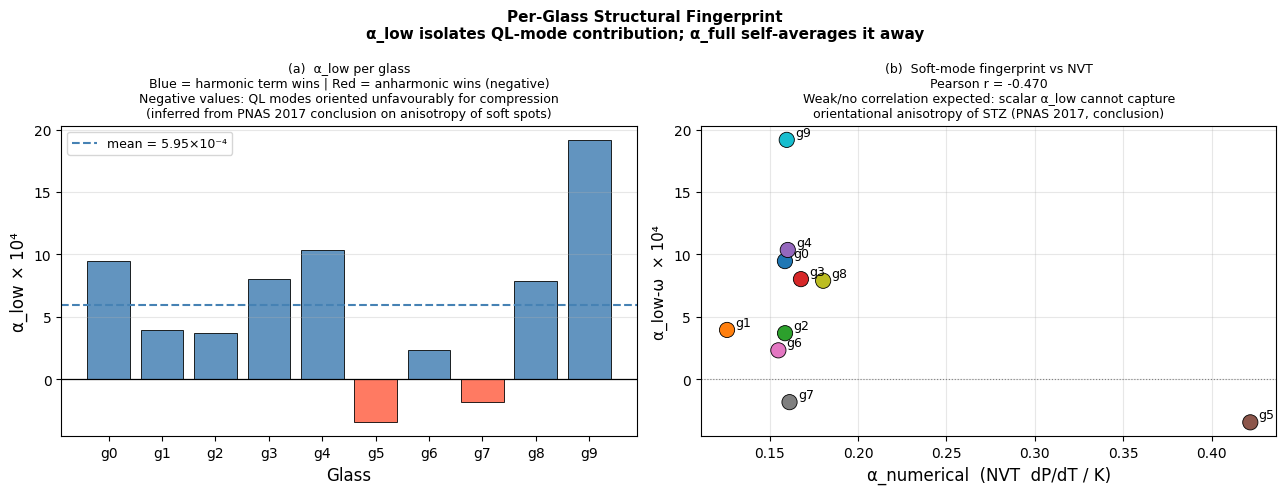

Glasses with negative alpha_low: [5, 7]

IMPORTANT: alpha_low ≠ alpha_numerical by design.
alpha_low is ~300x smaller (only 0.3% of total alpha signal).


In [41]:
al_v  = np.array([low_results[g]['alpha_low']    for g in GLASSES])
at_v  = np.array([theory_data[g]['total']        for g in GLASSES])
an_v  = np.array([alpha_numerical.get(g, np.nan) for g in GLASSES])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart of alpha_low per glass
ax = axes[0]
bar_c = ['tomato' if v < 0 else 'steelblue' for v in al_v]
ax.bar(GLASSES, al_v*1e4, color=bar_c, alpha=0.85, edgecolor='black', lw=0.7)
ax.axhline(0, color='black', lw=0.9)
ax.axhline((al_v*1e4).mean(), color='steelblue', ls='--', lw=1.5,
           label=f'mean = {(al_v*1e4).mean():.2f}×10⁻⁴')
ax.set_xticks(GLASSES)
ax.set_xticklabels([f'g{g}' for g in GLASSES], fontsize=10)
ax.set_xlabel('Glass', fontsize=12)
ax.set_ylabel('α_low × 10⁴', fontsize=12)
ax.set_title(
    '(a)  α_low per glass\n'
    'Blue = harmonic term wins | Red = anharmonic wins (negative)\n'
    'Negative values: QL modes oriented unfavourably for compression\n'
    f'(inferred from PNAS 2017 conclusion on anisotropy of soft spots)',
    fontsize=9)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Right: scatter alpha_low vs alpha_numerical
ax2 = axes[1]
valid = ~np.isnan(an_v)
ax2.scatter(an_v[valid], al_v[valid]*1e4,
            c=[colors[i] for i,v in enumerate(valid) if v],
            s=120, zorder=3, edgecolors='black', lw=0.6)
for i, g in enumerate(GLASSES):
    if valid[i]:
        ax2.annotate(f'g{g}', (an_v[i], al_v[i]*1e4),
                     textcoords='offset points', xytext=(6,3), fontsize=9)
r_corr = np.corrcoef(an_v[valid], al_v[valid])[0,1]
ax2.axhline(0, color='gray', lw=0.8, ls=':')
ax2.set_xlabel('α_numerical  (NVT  dP/dT / K)', fontsize=12)
ax2.set_ylabel('α_low-ω  × 10⁴', fontsize=11)
ax2.set_title(
    f'(b)  Soft-mode fingerprint vs NVT\n'
    f'Pearson r = {r_corr:.3f}\n'
    'Weak/no correlation expected: scalar α_low cannot capture\n'
    'orientational anisotropy of STZ (PNAS 2017, conclusion)',
    fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle(
    'Per-Glass Structural Fingerprint\n'
    'α_low isolates QL-mode contribution; α_full self-averages it away',
    fontsize=11, fontweight='bold')
fig.tight_layout()
plt.savefig(Path(DATA_DIR)/'fig4_alpha_low_perGlass.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Glasses with negative alpha_low: '
      f"{[g for g in GLASSES if low_results[g]['alpha_low'] < 0]}")
print()
print('IMPORTANT: alpha_low ≠ alpha_numerical by design.')
print('alpha_low is ~300x smaller (only 0.3% of total alpha signal).')


---
## Complete per-glass summary


In [42]:
# Complete summary table: all three alpha estimates side by side
alpha_low_dict = {g: low_results[g]['alpha_low'] for g in low_results}

print()
print("=" * 95)
print(f"  {'GLASS':<8}  {'alpha_numerical':>16}  {'alpha_full_theory':>18}  "
      f"{'alpha_low_omega':>17}  {'num/full':>9}  notes")
print("-" * 95)

for g in range(10):
    a_n   = alpha_numerical.get(g, float('nan'))
    a_t   = theory_data[g]['total'] if g in theory_data else float('nan')
    a_l   = alpha_low_dict.get(g, float('nan'))
    ratio = a_n/a_t if (not np.isnan(a_t) and a_t != 0) else float('nan')
    note  = (' <- outlier (g5 NVT)' if g == 5 else
             ' <- NEGATIVE low-omega'   if a_l < 0 else '')
    print(f"  g{g:<7}  {a_n:>+16.6e}  {a_t:>+18.6e}  {a_l:>+17.6e}  "
          f"{ratio:>9.4f}{note}")

print("-" * 95)

a_n_all = np.array([alpha_numerical.get(g, np.nan)  for g in range(10)])
a_t_all = np.array([theory_data[g]['total']          for g in range(10)])
a_l_all = np.array([alpha_low_dict.get(g, np.nan)   for g in range(10)])
mask    = (~np.isnan(a_n_all) &
           (np.abs(a_n_all-np.nanmedian(a_n_all)) < 3*np.nanstd(a_n_all[~np.isnan(a_n_all)])))

print()
print(f"  {'':8}  {'mean (all 10)':>16}  {'mean (all 10)':>18}  {'mean (all 10)':>17}")
print(f"  {'':8}  {np.nanmean(a_n_all):>+16.6e}  {a_t_all.mean():>+18.6e}  "
      f"{np.nanmean(a_l_all):>+17.6e}")
print()
print(f"  {'':8}  {'CV (excl g5)':>16}  {'CV (all)':>18}  {'CV (all)':>17}")
print(f"  {'':8}  {np.nanstd(a_n_all[mask])/np.nanmean(a_n_all[mask])*100:>15.2f}%  "
      f"{a_t_all.std()/a_t_all.mean()*100:>17.3f}%  "
      f"{np.nanstd(a_l_all)/np.nanmean(a_l_all)*100:>16.1f}%")
print("=" * 95)
print()
print("INTERPRETATION:")
print(f"  alpha_full CV = {a_t_all.std()/a_t_all.mean()*100:.3f}%  "
      f"<= CLT floor {100/np.sqrt(N_MODES):.2f}%  => self-averaging confirmed")
print(f"  alpha_low  CV = {np.nanstd(a_l_all)/np.nanmean(a_l_all)*100:.1f}%  "
      f"=> {np.nanstd(a_l_all)/np.nanmean(a_l_all)*100/(a_t_all.std()/a_t_all.mean()*100):.0f}x "
      f"larger — structural fingerprint exposed by QL-mode restriction")
print(f"  alpha_num  CV = {np.nanstd(a_n_all[mask])/np.nanmean(a_n_all[mask])*100:.2f}%  "
      f"(excl g5) — real glass-to-glass thermal variation from NVT")
print()
print("  alpha_full ≈ alpha_numerical in MAGNITUDE")



  GLASS      alpha_numerical   alpha_full_theory    alpha_low_omega   num/full  notes
-----------------------------------------------------------------------------------------------
  g0           +1.585592e-01       +1.855282e-01      +9.459831e-04     0.8546
  g1           +1.257985e-01       +1.855766e-01      +3.944457e-04     0.6779
  g2           +1.586224e-01       +1.871793e-01      +3.682266e-04     0.8474
  g3           +1.676210e-01       +1.875358e-01      +8.014944e-04     0.8938
  g4           +1.601689e-01       +1.885384e-01      +1.035307e-03     0.8495
  g5           +4.219535e-01       +1.849220e-01      -3.460049e-04     2.2818 <- outlier (g5 NVT)
  g6           +1.548517e-01       +1.843047e-01      +2.309521e-04     0.8402
  g7           +1.611652e-01       +1.847413e-01      -1.842970e-04     0.8724 <- NEGATIVE low-omega
  g8           +1.801850e-01       +1.863605e-01      +7.883774e-04     0.9669
  g9           +1.595863e-01       +1.857108e-01      +1.917602e